# Leaf Recognition Program
Train a CNN to classify mango and jackfruit leaf images using the prepared train/validation/test split.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
dataset_root = Path(r"c:\Users\alvee\Desktop\AI Lab\Leaf_Recognition\split_dataset")
image_size = (256, 256)
batch_size = 32
epochs = 20
model_output = Path(r"c:\Users\alvee\Desktop\AI Lab\Leaf_Recognition\leaf_recognition_model.keras")

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_root / "train",
    label_mode="int",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
)
validation_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_root / "validation",
    label_mode="int",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_root / "test",
    label_mode="int",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3464 files belonging to 2 classes.
Found 495 files belonging to 2 classes.
Found 989 files belonging to 2 classes.
Classes: ['aam_pata', 'kathal_pata']


In [9]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

model = models.Sequential([
    layers.Input(shape=(image_size[0], image_size[1], 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,234 (25.36 MB)

 Trainable params: 6,647,234 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr],
)

Epoch 1/20


c:\Users\alvee\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 301ms/step - accuracy: 0.5719 - loss: 0.6792 - val_accuracy: 0.6323 - val_loss: 0.6208 - learning_rate: 0.0010
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 296ms/step - accuracy: 0.6611 - loss: 0.6145 - val_accuracy: 0.7010 - val_loss: 0.5516 - learning_rate: 0.0010
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 297ms/step - accuracy: 0.6871 - loss: 0.5786 - val_accuracy: 0.7818 - val_loss: 0.4989 - learning_rate: 0.0010
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 297ms/step - accuracy: 0.7272 - loss: 0.5449 - val_accuracy: 0.7737 - val_loss: 0.4902 - learning_rate: 0.0010
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 296ms/step - accuracy: 0.7439 - loss: 0.5090 - val_accuracy: 0.7111 - val_loss: 0.5361 - learning_rate: 0.0010
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.7685 - loss: 0.4837 - val_accuracy: 0.8242 - val_loss: 0.4215 - learning_rate: 0.0010
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 307ms/step - accuracy: 0.7693 - loss:

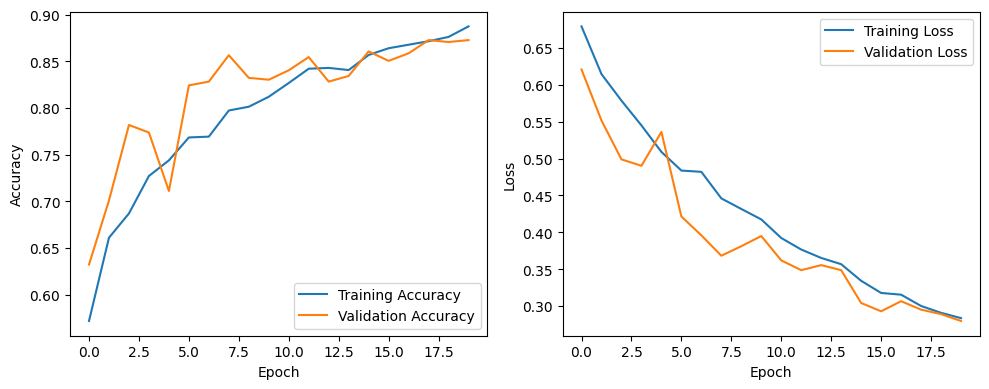

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

model.save(model_output)
print(f"Saved model to: {model_output}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8827 - loss: 0.2869
Test Loss: 0.2869
Test Accuracy: 0.8827
Saved model to: c:\Users\alvee\Desktop\AI Lab\Leaf_Recognition\leaf_recognition_model.keras
